In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize']=(14,6)

# Load the datasets

In [2]:
data=pd.read_csv('../datasets/PJME_preprocessd.csv',parse_dates=['Datetime'],index_col='Datetime')

In [3]:
data.head()

,PJME_MW,PJME_MW_Scaled,Hour,Day,Week,Month,DayOfWeek,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,RollingMean_24,RollingStd_24,RollingMean_168
Datetime,,,,,,,,,,,,,,,
2002-01-08 01:00:00,29445.0,0.433011,1,8,2,1,1,0,31187.0,26862.0,27100.0,30393.0,33560.208333,4425.965952,32513.869048
2002-01-08 02:00:00,28670.0,0.409021,2,8,2,1,1,0,29445.0,25976.0,26097.0,29265.0,33672.458333,4256.159403,32510.327381
2002-01-08 03:00:00,28375.0,0.399889,3,8,2,1,1,0,28670.0,25641.0,25793.0,28357.0,33786.375000,4064.104959,32510.434524
2002-01-08 04:00:00,28542.0,0.405058,4,8,2,1,1,0,28375.0,25666.0,25657.0,27899.0,33906.208333,3851.076461,32514.261905
2002-01-08 05:00:00,29261.0,0.427316,5,8,2,1,1,0,28542.0,26328.0,25778.0,28057.0,34028.416667,3640.941409,32521.428571


# Select the target column


In [4]:
target=data['PJME_MW_Scaled']
target.head()

Datetime
2002-01-08 01:00:00    0.433011
2002-01-08 02:00:00    0.409021
2002-01-08 03:00:00    0.399889
2002-01-08 04:00:00    0.405058
2002-01-08 05:00:00    0.427316
Name: PJME_MW_Scaled, dtype: float64

In [5]:
train_size = int(len(target)*0.80)
train= target.iloc[:train_size]
test= target.iloc[train_size:]
print('Training samples:',len(train))
print('Testing samples :',len(test))

Training samples: 116179
Testing samples : 29045


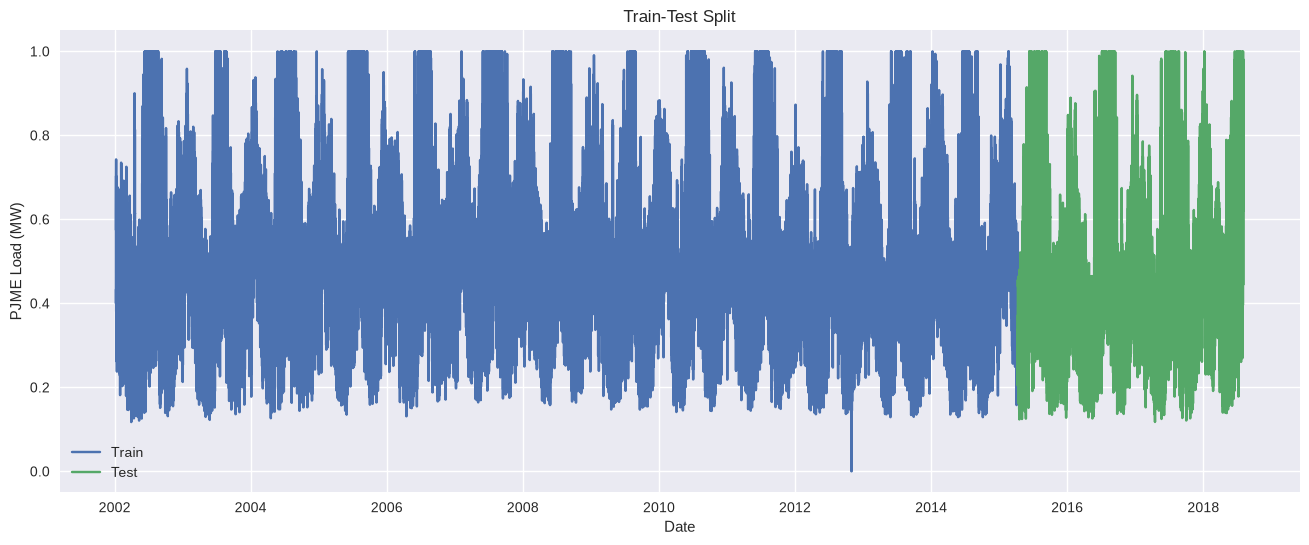

In [6]:
plt.figure(figsize=(16,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('PJME Load (MW)')
plt.legend()
plt.show()

# Naive Forecast Model

In [7]:
naive_forecast=test.shift(1)
#remove first nan balue
naive_forecast=naive_forecast.dropna()
naive_actual=test.iloc[1:]

In [8]:
naive_forecast.head()

Datetime
2015-04-10 21:00:00    0.440441
2015-04-10 22:00:00    0.455919
2015-04-10 23:00:00    0.425025
2015-04-11 00:00:00    0.367447
2015-04-11 01:00:00    0.307485
Name: PJME_MW_Scaled, dtype: float64

In [10]:
# Evaluation
naive_mae=mean_absolute_error(naive_actual,naive_forecast)
naive_rmse=np.sqrt(mean_squared_error(naive_actual,naive_forecast))
print("Naive MAE :", round(naive_mae,3))
print("Naive RMSE:", round(naive_rmse,3
                          ))

Naive MAE : 0.032
Naive RMSE: 0.042


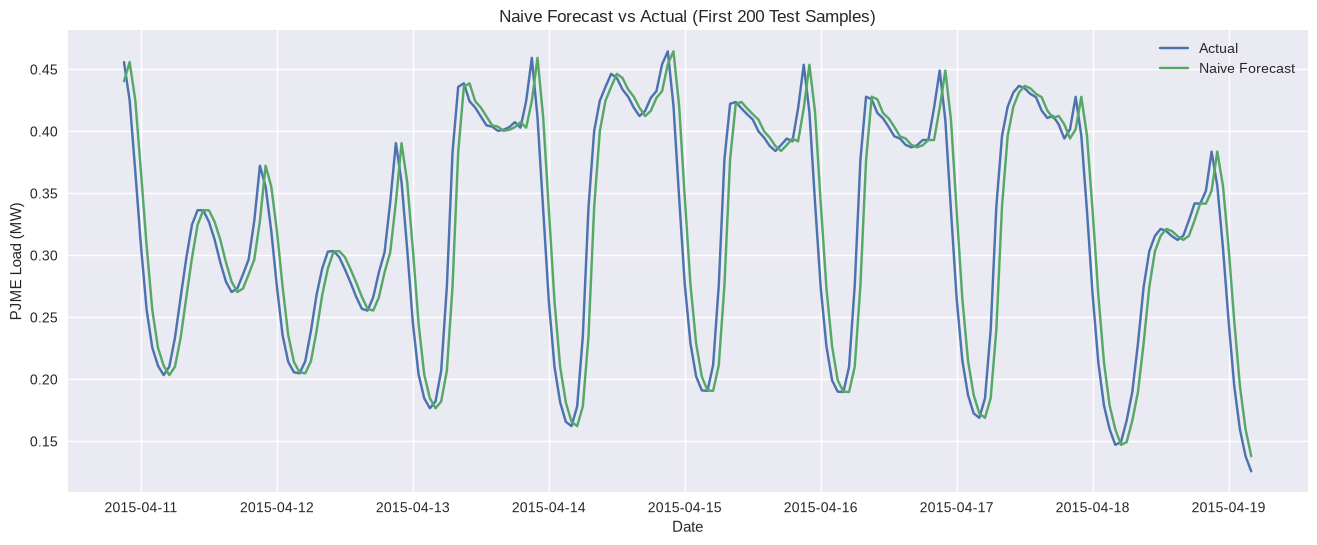

In [11]:
plt.figure(figsize=(16,6))
plt.plot(naive_actual.index[:200], naive_actual.values[:200], label='Actual')
plt.plot(naive_forecast.index[:200], naive_forecast.values[:200], label='Naive Forecast')
plt.title('Naive Forecast vs Actual (First 200 Test Samples)')
plt.xlabel('Date')
plt.ylabel('PJME Load (MW)')
plt.legend()
plt.show()

# Moving Average Forecast

In [12]:
moving_avg_forecast = test.rolling(window=24).mean()
moving_avg_forecast = moving_avg_forecast.dropna()
moving_avg_actual = test.iloc[23:]

In [13]:
moving_avg_forecast.head()

Datetime
2015-04-11 19:00:00    0.301481
2015-04-11 20:00:00    0.296791
2015-04-11 21:00:00    0.293309
2015-04-11 22:00:00    0.290414
2015-04-11 23:00:00    0.288425
Name: PJME_MW_Scaled, dtype: float64

In [14]:
moving_avg_mae = mean_absolute_error(moving_avg_actual, moving_avg_forecast)
moving_avg_rmse = np.sqrt(mean_squared_error(moving_avg_actual, moving_avg_forecast))
print("Moving Average MAE :", round(moving_avg_mae, 3))
print("Moving Average RMSE:", round(moving_avg_rmse, 3))

Moving Average MAE : 0.11
Moving Average RMSE: 0.136


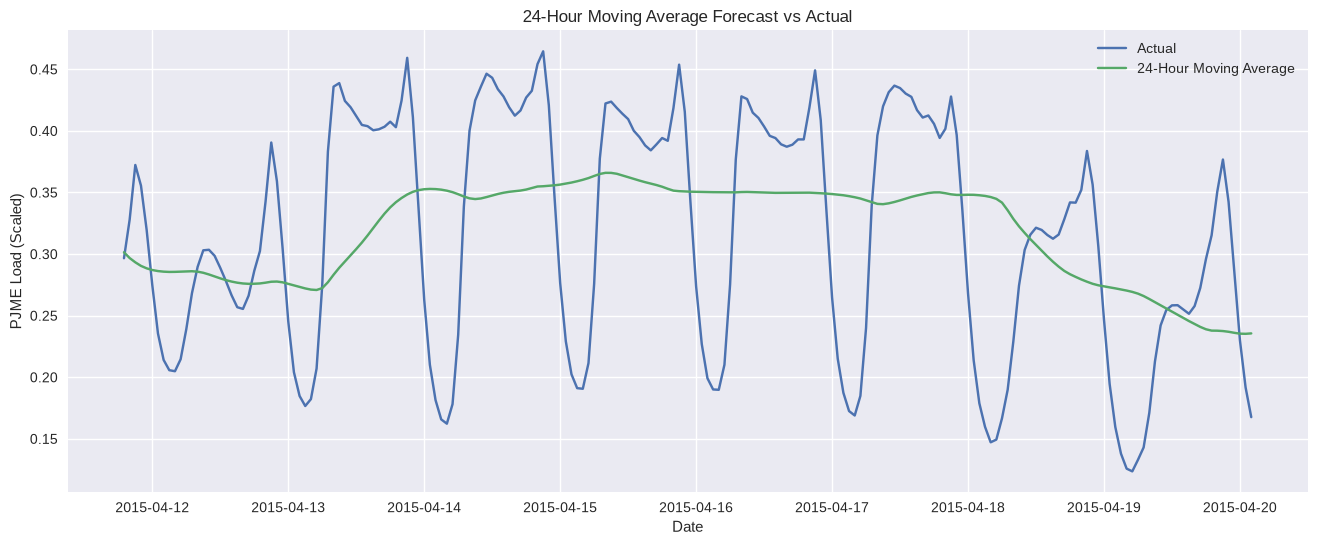

In [15]:
plt.figure(figsize=(16,6))
plt.plot(moving_avg_actual.index[:200], moving_avg_actual.values[:200], label='Actual')
plt.plot(moving_avg_forecast.index[:200], moving_avg_forecast.values[:200], label='24-Hour Moving Average')
plt.title('24-Hour Moving Average Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('PJME Load (Scaled)')
plt.legend()
plt.show()

# Previous-Day Forecast

In [16]:
prev_day_forecast = test.shift(24)
prev_day_forecast = prev_day_forecast.dropna()
prev_day_actual = test.iloc[24:]
prev_day_forecast.head()

Datetime
2015-04-11 20:00:00    0.440441
2015-04-11 21:00:00    0.455919
2015-04-11 22:00:00    0.425025
2015-04-11 23:00:00    0.367447
2015-04-12 00:00:00    0.307485
Name: PJME_MW_Scaled, dtype: float64

In [17]:
prev_day_mae = mean_absolute_error(prev_day_actual, prev_day_forecast)
prev_day_rmse = np.sqrt(mean_squared_error(prev_day_actual, prev_day_forecast))
print("Previous-Day MAE :", round(prev_day_mae, 3))
print("Previous-Day RMSE:", round(prev_day_rmse, 3))

Previous-Day MAE : 0.066
Previous-Day RMSE: 0.091


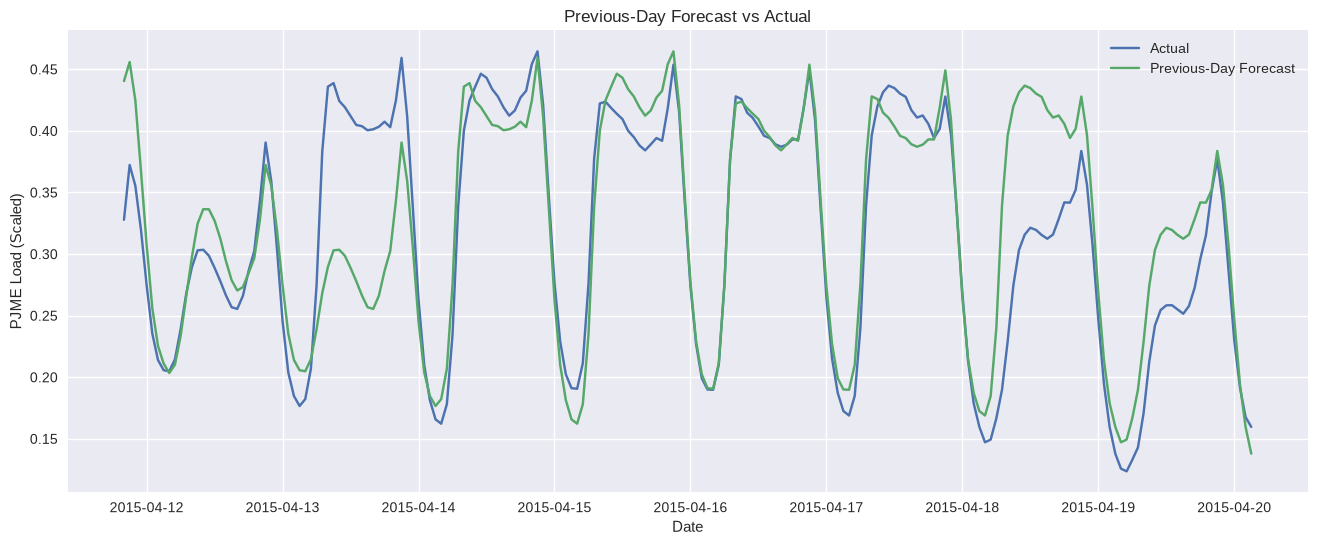

In [18]:
plt.figure(figsize=(16,6))
plt.plot(prev_day_actual.index[:200], prev_day_actual.values[:200], label='Actual')
plt.plot(prev_day_forecast.index[:200], prev_day_forecast.values[:200], label='Previous-Day Forecast')
plt.title('Previous-Day Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('PJME Load (Scaled)')
plt.legend()
plt.show()

# Previous-Week Forecast

In [20]:
prev_week_forecast = test.shift(168)
prev_week_forecast = prev_week_forecast.dropna()
prev_week_actual = test.iloc[168:]
prev_week_forecast.head()

Datetime
2015-04-17 20:00:00    0.440441
2015-04-17 21:00:00    0.455919
2015-04-17 22:00:00    0.425025
2015-04-17 23:00:00    0.367447
2015-04-18 00:00:00    0.307485
Name: PJME_MW_Scaled, dtype: float64

In [21]:
prev_week_mae = mean_absolute_error(prev_week_actual, prev_week_forecast)
prev_week_rmse = np.sqrt(mean_squared_error(prev_week_actual, prev_week_forecast))
print("Previous-Week MAE :", round(prev_week_mae, 3))
print("Previous-Week RMSE:", round(prev_week_rmse, 3))

Previous-Week MAE : 0.102
Previous-Week RMSE: 0.139


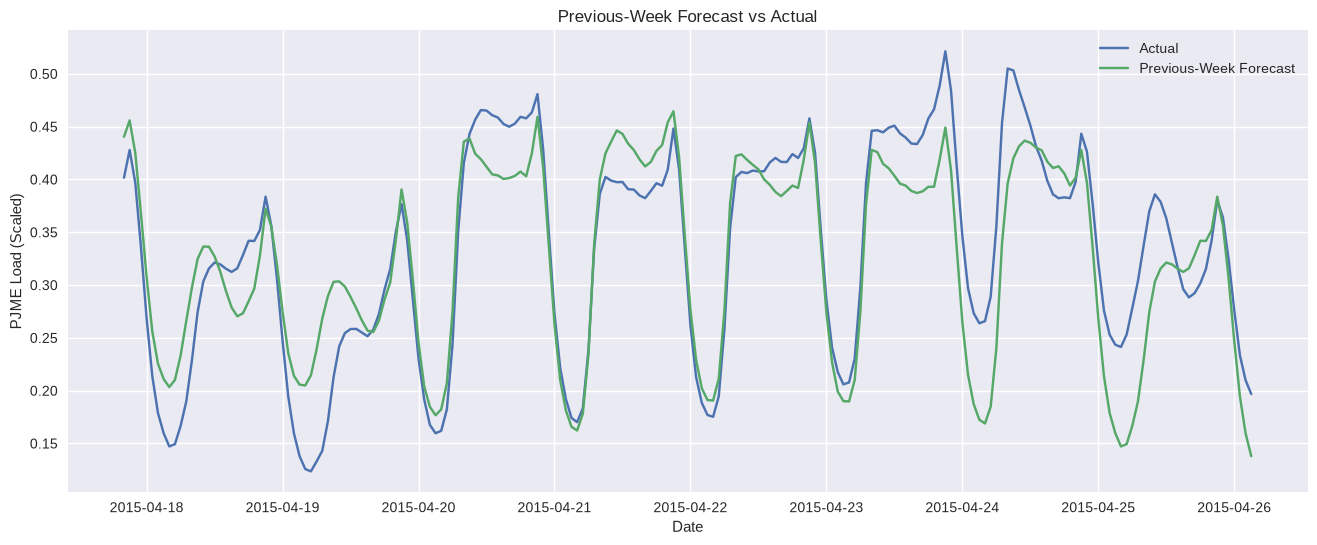

In [22]:
plt.figure(figsize=(16,6))
plt.plot(prev_week_actual.index[:200], prev_week_actual.values[:200], label='Actual')
plt.plot(prev_week_forecast.index[:200], prev_week_forecast.values[:200], label='Previous-Week Forecast')
plt.title('Previous-Week Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('PJME Load (Scaled)')
plt.legend()
plt.show()

In [23]:
comparison = pd.DataFrame({
    'Model':['Naive Forecast','Moving Average','Previous-Day Forecast','Previous-Week Forecast'],
    'MAE':[naive_mae,moving_avg_mae,prev_day_mae,prev_week_mae],
    'RMSE':[naive_rmse,moving_avg_rmse,prev_day_rmse,prev_week_rmse]
})
comparison


,Model,MAE,RMSE
0,Naive Forecast,0.032438,0.042093
1,Moving Average,0.110163,0.136381
2,Previous-Day Forecast,0.065635,0.090694
3,Previous-Week Forecast,0.102124,0.139421


`Naive Forest is best baseline model compare then other three model

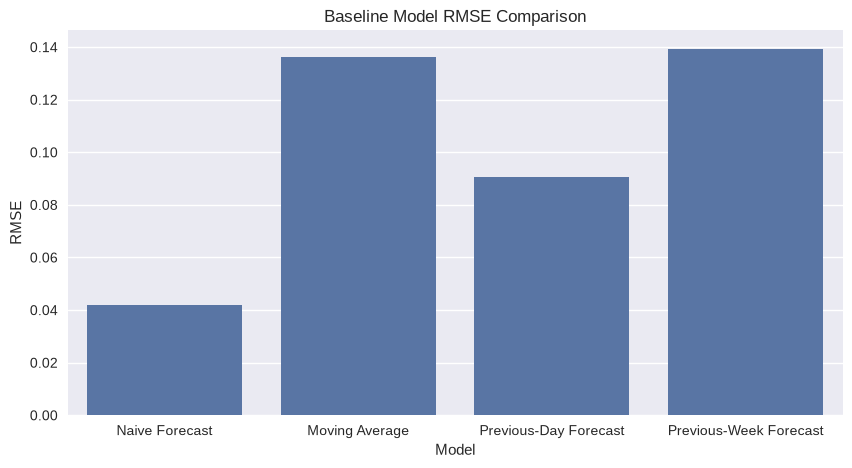

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(data=comparison, x='Model', y='RMSE')
plt.title('Baseline Model RMSE Comparison')
plt.ylabel('RMSE')
plt.show()